# Assignment 8 — Target Model and Optimization

Primary model: **Ridge Regression F1** with expanded hyperparameter search.  
Nonlinear benchmark: **Random Forest F1** (sklearn).  
Reference baselines from Assignment 7: Dummy F0, OLS F0, Ridge F1 (alpha=0.1), Decision Tree F1.  
Target variable: `hospital_use_per_1000` | seed: 42 | primary metric: holdout RMSE

In [4]:
from pathlib import Path
import json, math, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

SEED, TEST_SIZE, CV_SPLITS = 42, 0.2, 5
TARGET, GROUP = "hospital_use_per_1000", "PracticeCode"
ROOT = Path.cwd()
if ROOT.name == "assignment8":
    ROOT = ROOT.parent

print(f"Python: {sys.version}")

Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


## 1. Data Loading

Same pipeline as Assignment 7. No preprocessing choices are changed.

In [5]:
raw_dir = ROOT / "assignment4" / "data" / "raw"
dem_path = raw_dir / "sample_gp_practice_population_demographics.csv"
sup_path = raw_dir / "sample_gp_practice_supporting_inputs.csv"

dem = pd.read_csv(dem_path, parse_dates=["Date"])
sup = pd.read_csv(sup_path, parse_dates=["Date"])
dem[GROUP] = dem[GROUP].astype(str)
sup[GROUP] = sup[GROUP].astype(str)

age_cols = ["AllAges", "Ages0to4", "Ages5to14", "Ages15to24", "Ages25to44",
            "Ages45to64", "Ages65to74", "Ages75to84", "Ages85plus"]
dem[age_cols] = dem[age_cols].apply(pd.to_numeric, errors="coerce")

keys = ["Date", GROUP]
valid_keys = dem.groupby(keys)["Sex"].agg(lambda s: {"All", "Female"}.issubset(set(s)))
valid_keys = valid_keys[valid_keys].index
base = dem.set_index(keys).loc[valid_keys].reset_index()

all_rows = base[base["Sex"].eq("All")].copy()
female = (base[base["Sex"].eq("Female")][keys + ["AllAges"]]
          .rename(columns={"AllAges": "female_population"}))
df = all_rows[keys + ["HB", "HSCP"] + age_cols].merge(female, on=keys, validate="1:1")
df = df[df["AllAges"].fillna(0).gt(0)].copy()

df["share_age_0_14"]   = (df["Ages0to4"] + df["Ages5to14"]) / df["AllAges"]
df["share_age_65_plus"]= (df["Ages65to74"] + df["Ages75to84"] + df["Ages85plus"]) / df["AllAges"]
df["share_female"]     = df["female_population"] / df["AllAges"]
df["log_all_ages"]     = np.log1p(df["AllAges"])

df = df.merge(sup[keys + ["gp_availability", "deprivation_index", TARGET]], on=keys, validate="1:1")
df = df.sort_values(["Date", GROUP]).reset_index(drop=True)
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

print(f"Dataset: {len(df)} rows, {df[GROUP].nunique()} practices")
print(f"Target stats — mean: {df[TARGET].mean():.3f}, std: {df[TARGET].std():.3f}")
df.head()

Dataset: 12 rows, 4 practices
Target stats — mean: 285.750, std: 38.357


,Date,PracticeCode,HB,HSCP,AllAges,Ages0to4,Ages5to14,Ages15to24,Ages25to44,Ages45to64,...,Ages75to84,Ages85plus,female_population,share_age_0_14,share_age_65_plus,share_female,log_all_ages,gp_availability,deprivation_index,hospital_use_per_1000
0,2024-01-01,1001,NHS_Lothian,Edinburgh_North,5400,260,580,720,1480,1360,...,310,130,2790,0.155556,0.185185,0.516667,8.594339,0.68,18.2,268.4
1,2024-01-01,1002,NHS_Lothian,Edinburgh_West,4300,210,470,560,1170,1100,...,230,90,2235,0.158140,0.183721,0.519767,8.366603,0.63,24.9,286.7
2,2024-01-01,1003,NHS_Greater_Glasgow,Glasgow_Central,6100,340,760,840,1710,1500,...,250,90,3205,0.180328,0.155738,0.525410,8.716208,0.51,41.3,347.9
3,2024-01-01,1004,NHS_Grampian,Aberdeen_City,3900,180,420,500,990,1010,...,240,90,2015,0.153846,0.205128,0.516667,8.268988,0.73,20.8,248.6
4,2024-02-01,1001,NHS_Lothian,Edinburgh_North,5425,262,582,724,1486,1368,...,311,130,2802,0.155576,0.184885,0.516498,8.598957,0.69,18.1,267.2


## 2. Train / Test Split

Identical PracticeCode-aware split to Assignment 7 (seed 42, 20% test groups).

In [6]:
rng = np.random.default_rng(SEED)
groups = np.array(sorted(df[GROUP].unique()))
test_n = max(1, math.ceil(TEST_SIZE * len(groups)))
test_groups = set(rng.permutation(groups)[:test_n])

is_test = df[GROUP].isin(test_groups)
train = df[~is_test].reset_index(drop=True)
test  = df[is_test].reset_index(drop=True)

fold_count = min(CV_SPLITS, train[GROUP].nunique())
rng2 = np.random.default_rng(SEED)
fold_groups = np.array_split(rng2.permutation(sorted(train[GROUP].unique())), fold_count)
folds = [(train[~train[GROUP].isin(g)].copy(),
          train[train[GROUP].isin(g)].copy()) for g in fold_groups]

print(f"Train: {len(train)} rows ({train[GROUP].nunique()} practices)")
print(f"Test : {len(test)} rows  ({test[GROUP].nunique()} practices): {sorted(test_groups)}")
print(f"CV folds (group-aware): {fold_count}")

Train: 9 rows (3 practices)
Test : 3 rows  (1 practices): [np.str_('1004')]
CV folds (group-aware): 3


## 3. Feature Sets and Helper Functions

In [7]:
F0 = ["log_all_ages", "gp_availability"]
F1 = F0 + ["share_age_65_plus", "share_female", "deprivation_index"]
CAT = ["HB", "HSCP"]

def design_matrix(fit_df, apply_df, numeric, categorical):
    """Fit scaler on fit_df, apply to apply_df. Returns numpy array and column names."""
    med = fit_df[numeric].median()
    x_fit = fit_df[numeric].fillna(med).astype(float)
    mean_, std_ = x_fit.mean(), x_fit.std(ddof=0).replace(0, 1)
    parts = [((apply_df[numeric].fillna(med).astype(float) - mean_) / std_).reset_index(drop=True)]
    for col in categorical:
        mode_ = fit_df[col].mode(dropna=True)
        mode_ = mode_.iloc[0] if len(mode_) else "__missing__"
        levels = sorted(fit_df[col].fillna(mode_).astype(str).unique())
        cat = pd.Series(pd.Categorical(apply_df[col].fillna(mode_).astype(str),
                                       categories=levels), name=col)
        parts.append(pd.get_dummies(cat, prefix=col).astype(float).reset_index(drop=True))
    x = pd.concat(parts, axis=1)
    return x.to_numpy(float), list(x.columns)

def reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    err  = y_true - y_pred
    denom = float(((y_true - y_true.mean()) ** 2).sum())
    r2   = round(1 - float((err ** 2).sum()) / denom, 6) if denom else None
    rmse = round(math.sqrt(float((err ** 2).mean())), 6)
    mae  = round(float(np.abs(err).mean()), 6)
    return {"r2": r2, "rmse": rmse, "mae": mae}

def fit_ridge(x, y, alpha=1.0):
    z = np.c_[np.ones(len(x)), x]
    pen = np.eye(z.shape[1]) * alpha
    pen[0, 0] = 0
    return np.linalg.pinv(z.T @ z + pen) @ z.T @ y

def predict_ridge(beta, x):
    return np.c_[np.ones(len(x)), x] @ beta

print("Feature sets:")
print(f"  F0 ({len(F0)} numeric): {F0}")
print(f"  F1 ({len(F1)} numeric + {len(CAT)} categorical): {F1} | cat: {CAT}")

Feature sets:
  F0 (2 numeric): ['log_all_ages', 'gp_availability']
  F1 (5 numeric + 2 categorical): ['log_all_ages', 'gp_availability', 'share_age_65_plus', 'share_female', 'deprivation_index'] | cat: ['HB', 'HSCP']


## 4. Ridge F1 — Expanded Alpha Grid (Primary Model)

Assignment 7 searched α ∈ {0.1, 1.0, 10.0}. Assignment 8 expands this to seven orders of magnitude to confirm the optimal regularisation strength.

In [8]:
ALPHA_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

ridge_cv_results = []
for alpha in ALPHA_GRID:
    fold_scores = []
    for ftr, fva in folds:
        xtr, _ = design_matrix(ftr, ftr, F1, CAT)
        xva, _ = design_matrix(ftr, fva, F1, CAT)
        ytr = ftr[TARGET].to_numpy(float)
        yva = fva[TARGET].to_numpy(float)
        beta = fit_ridge(xtr, ytr, alpha=alpha)
        fold_scores.append(reg_metrics(yva, predict_ridge(beta, xva)))
    mean_rmse = np.mean([s["rmse"] for s in fold_scores])
    mean_r2   = np.mean([s["r2"]   for s in fold_scores if s["r2"] is not None])
    std_rmse  = np.std([s["rmse"]  for s in fold_scores], ddof=1) if len(fold_scores) > 1 else 0.0
    ridge_cv_results.append({"alpha": alpha, "cv_mean_rmse": round(mean_rmse, 4),
                              "cv_std_rmse": round(std_rmse, 4), "cv_mean_r2": round(float(mean_r2), 4)})

ridge_cv_df = pd.DataFrame(ridge_cv_results)
best_alpha = ridge_cv_df.loc[ridge_cv_df["cv_mean_rmse"].idxmin(), "alpha"]
print(f"Best alpha (CV RMSE criterion): {best_alpha}")
print()
print(ridge_cv_df.to_string(index=False))

Best alpha (CV RMSE criterion): 0.01

   alpha  cv_mean_rmse  cv_std_rmse  cv_mean_r2
   0.001        9.4396       4.8870    -28.9057
   0.010        4.8357       5.3228     -6.6730
   0.100        8.3142       3.6716    -38.2305
   1.000       14.8238       6.7899   -122.6510
  10.000       14.3538       6.1308   -161.3466
 100.000       30.2656      18.7387   -580.0484
1000.000       43.8502      23.1067   -970.3960


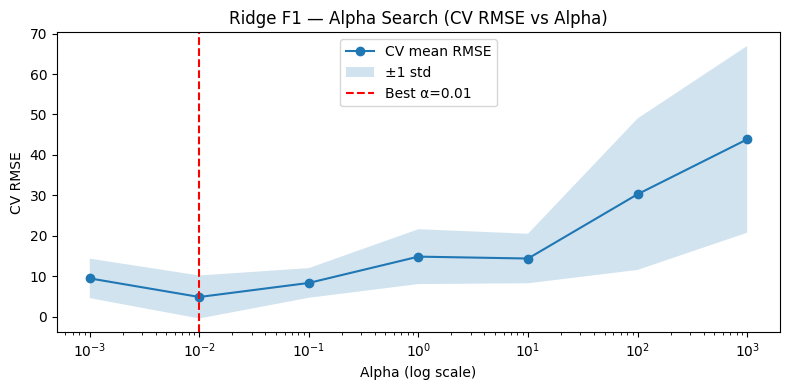

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ridge_cv_df["alpha"], ridge_cv_df["cv_mean_rmse"], "o-", label="CV mean RMSE")
ax.fill_between(
    ridge_cv_df["alpha"],
    ridge_cv_df["cv_mean_rmse"] - ridge_cv_df["cv_std_rmse"],
    ridge_cv_df["cv_mean_rmse"] + ridge_cv_df["cv_std_rmse"],
    alpha=0.2, label="\u00b11 std"
)
ax.axvline(best_alpha, color="red", linestyle="--", label=f"Best \u03b1={best_alpha}")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("CV RMSE")
ax.set_title("Ridge F1 \u2014 Alpha Search (CV RMSE vs Alpha)")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Refit on full training set with best alpha, evaluate on held-out test
xtr_full, feat_cols = design_matrix(train, train, F1, CAT)
xte_full, _         = design_matrix(train, test,  F1, CAT)
ytr_full = train[TARGET].to_numpy(float)
yte_full = test[TARGET].to_numpy(float)

beta_best = fit_ridge(xtr_full, ytr_full, alpha=best_alpha)
pred_ridge = predict_ridge(beta_best, xte_full)
holdout_ridge = reg_metrics(yte_full, pred_ridge)

print(f"Ridge F1 (alpha={best_alpha}) — holdout metrics:")
print(f"  R²:   {holdout_ridge['r2']}")
print(f"  RMSE: {holdout_ridge['rmse']}")
print(f"  MAE:  {holdout_ridge['mae']}")

# Coefficients
coef_df = pd.DataFrame({"feature": ["intercept"] + feat_cols,
                         "coefficient": beta_best.round(4)})
print()
print(coef_df.to_string(index=False))

Ridge F1 (alpha=0.01) — holdout metrics:
  R²:   0.46853
  RMSE: 1.340287
  MAE:  1.335339

               feature  coefficient
             intercept     299.3095
          log_all_ages      -0.0789
       gp_availability     -11.0318
     share_age_65_plus     -10.0536
          share_female       4.7813
     deprivation_index       5.6734
HB_NHS_Greater_Glasgow       1.2285
        HB_NHS_Lothian      -1.2285
  HSCP_Edinburgh_North      -1.1286
   HSCP_Edinburgh_West      -0.0999
  HSCP_Glasgow_Central       1.2285


## 5. Random Forest F1 — Nonlinear Benchmark

As specified in Assignment 3, Random Forest checks whether nonlinear interactions provide gain beyond Ridge F1. Tuning uses group-aware CV on the training partition.

In [11]:
RF_GRID = [
    {"n_estimators": 50,  "max_depth": 2, "min_samples_leaf": 2},
    {"n_estimators": 50,  "max_depth": 3, "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 2, "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 3, "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 3, "min_samples_leaf": 4},
    {"n_estimators": 200, "max_depth": 3, "min_samples_leaf": 2},
]

rf_cv_results = []
for params in RF_GRID:
    fold_scores = []
    for ftr, fva in folds:
        xtr, _ = design_matrix(ftr, ftr, F1, CAT)
        xva, _ = design_matrix(ftr, fva, F1, CAT)
        ytr    = ftr[TARGET].to_numpy(float)
        yva    = fva[TARGET].to_numpy(float)
        rf = RandomForestRegressor(random_state=SEED, **params)
        rf.fit(xtr, ytr)
        fold_scores.append(reg_metrics(yva, rf.predict(xva)))
    mean_rmse = np.mean([s["rmse"] for s in fold_scores])
    std_rmse  = np.std([s["rmse"]  for s in fold_scores], ddof=1) if len(fold_scores) > 1 else 0.0
    rf_cv_results.append({**params, "cv_mean_rmse": round(mean_rmse, 4),
                           "cv_std_rmse": round(std_rmse, 4)})

rf_cv_df = pd.DataFrame(rf_cv_results)
best_rf_idx = rf_cv_df["cv_mean_rmse"].idxmin()
best_rf_params = RF_GRID[best_rf_idx]
print(f"Best RF params (CV RMSE): {best_rf_params}")
print()
print(rf_cv_df.to_string(index=False))

Best RF params (CV RMSE): {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 2}

 n_estimators  max_depth  min_samples_leaf  cv_mean_rmse  cv_std_rmse
           50          2                 2       35.1115      30.8427
           50          3                 2       35.1115      30.8427
          100          2                 2       34.8979      31.3020
          100          3                 2       34.8979      31.3020
          100          3                 4       45.6969      24.0316
          200          3                 2       34.1703      31.9635


In [12]:
# Refit RF on full training set, evaluate on test
rf_best = RandomForestRegressor(random_state=SEED, **best_rf_params)
rf_best.fit(xtr_full, ytr_full)
pred_rf = rf_best.predict(xte_full)
holdout_rf = reg_metrics(yte_full, pred_rf)

# Feature importances
fi_df = pd.DataFrame({"feature": feat_cols, "importance": rf_best.feature_importances_.round(4)})
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Random Forest F1 {best_rf_params} — holdout metrics:")
print(f"  R²:   {holdout_rf['r2']}")
print(f"  RMSE: {holdout_rf['rmse']}")
print(f"  MAE:  {holdout_rf['mae']}")
print()
print("Feature importances:")
print(fi_df.to_string(index=False))

Random Forest F1 {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 2} — holdout metrics:
  R²:   -297.003634
  RMSE: 31.737238
  MAE:  31.683702

Feature importances:
               feature  importance
     deprivation_index      0.1899
          share_female      0.1754
     share_age_65_plus      0.1334
          log_all_ages      0.1268
       gp_availability      0.1153
HB_NHS_Greater_Glasgow      0.0975
  HSCP_Glasgow_Central      0.0974
        HB_NHS_Lothian      0.0495
  HSCP_Edinburgh_North      0.0131
   HSCP_Edinburgh_West      0.0018


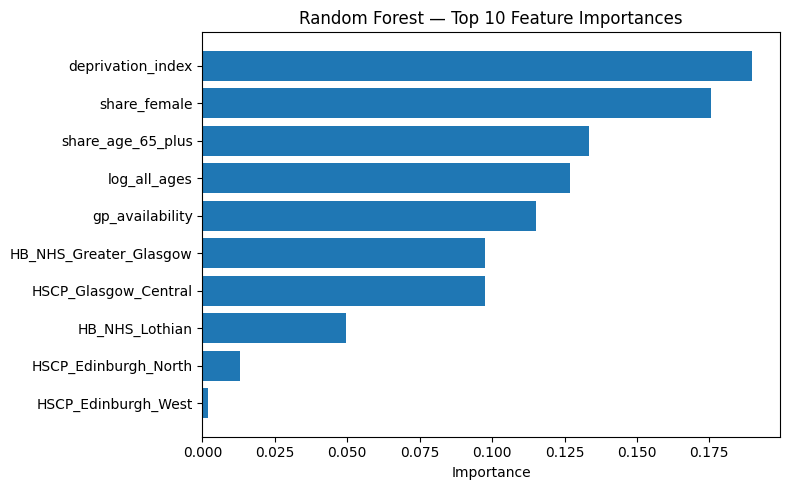

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
top_n = min(15, len(fi_df))
fi_top = fi_df.head(top_n)
ax.barh(fi_top["feature"].iloc[::-1].values, fi_top["importance"].iloc[::-1].values)
ax.set_xlabel("Importance")
ax.set_title(f"Random Forest \u2014 Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 6. Generalization Analysis — Train vs Validation Performance

In [14]:
# Train RMSE vs CV RMSE for Ridge across alpha values (overfitting diagnostic)
train_rmse_by_alpha = []
for alpha in ALPHA_GRID:
    xtr, _ = design_matrix(train, train, F1, CAT)
    ytr    = train[TARGET].to_numpy(float)
    beta   = fit_ridge(xtr, ytr, alpha=alpha)
    train_pred = predict_ridge(beta, xtr)
    train_rmse_by_alpha.append(reg_metrics(ytr, train_pred)["rmse"])

lc_df = pd.DataFrame({
    "alpha":      ALPHA_GRID,
    "train_rmse": [round(r, 4) for r in train_rmse_by_alpha],
    "cv_rmse":    ridge_cv_df["cv_mean_rmse"].values,
    "cv_std":     ridge_cv_df["cv_std_rmse"].values,
})
lc_df["gap_rmse"] = (lc_df["cv_rmse"] - lc_df["train_rmse"]).round(4)
print("Ridge generalisation — train vs CV RMSE across alpha:")
print(lc_df.to_string(index=False))

Ridge generalisation — train vs CV RMSE across alpha:
   alpha  train_rmse  cv_rmse  cv_std  gap_rmse
   0.001      0.2440   9.4396  4.8870    9.1956
   0.010      0.3852   4.8357  5.3228    4.4505
   0.100      0.5586   8.3142  3.6716    7.7556
   1.000      1.0708  14.8238  6.7899   13.7530
  10.000      6.2937  14.3538  6.1308    8.0601
 100.000     22.9161  30.2656 18.7387    7.3495
1000.000     31.8051  43.8502 23.1067   12.0451


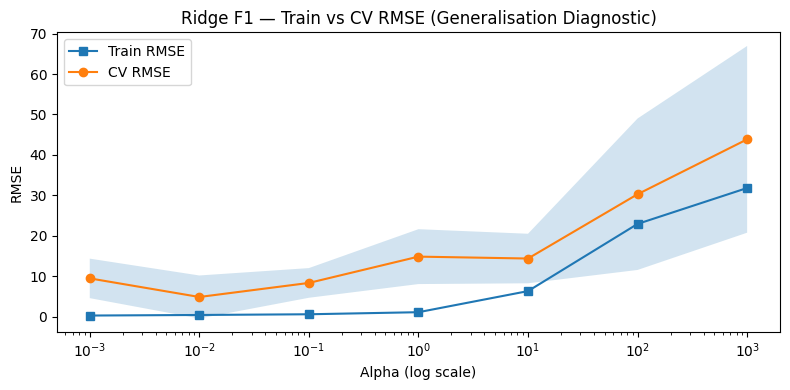

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lc_df["alpha"], lc_df["train_rmse"], "s-", label="Train RMSE")
ax.semilogx(lc_df["alpha"], lc_df["cv_rmse"], "o-", label="CV RMSE")
ax.fill_between(
    lc_df["alpha"],
    lc_df["cv_rmse"] - lc_df["cv_std"],
    lc_df["cv_rmse"] + lc_df["cv_std"],
    alpha=0.2
)
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("RMSE")
ax.set_title("Ridge F1 \u2014 Train vs CV RMSE (Generalisation Diagnostic)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Comparative Evaluation — All Models

In [16]:
# Reference baselines from Assignment 7 (hardcoded from documented results)
A7_BASELINES = [
    {"model": "Dummy mean (A7)",          "features": "F0", "params": "{}",
     "test_r2": -818.568, "test_rmse": 52.632, "test_mae": 52.600,
     "cv_r2": -1039.550,  "cv_rmse": 45.871,  "source": "assignment7"},
    {"model": "OLS F0 (A7)",              "features": "F0", "params": '{"alpha": 0.0}',
     "test_r2": -16.617,  "test_rmse": 7.717,  "test_mae": 7.539,
     "cv_r2": -686.193,   "cv_rmse": 43.961,   "source": "assignment7"},
    {"model": "Ridge F1 alpha=0.1 (A7)",  "features": "F1", "params": '{"alpha": 0.1}',
     "test_r2": -18.357,  "test_rmse": 8.089,  "test_mae": 8.083,
     "cv_r2": -38.230,    "cv_rmse": 8.314,    "source": "assignment7"},
    {"model": "Decision Tree F1 (A7)",    "features": "F1", "params": '{"max_depth": 3, "min_leaf": 2}',
     "test_r2": -438.536, "test_rmse": 38.544, "test_mae": 38.500,
     "cv_r2": -2289.320,  "cv_rmse": 57.627,   "source": "assignment7"},
]

# Assignment 8 new models
best_rf_cv = rf_cv_df.loc[best_rf_idx, "cv_mean_rmse"]
A8_MODELS = [
    {"model": f"Ridge F1 alpha={best_alpha} (A8 primary)",
     "features": "F1", "params": f'{{"alpha": {best_alpha}}}',
     "test_r2": holdout_ridge["r2"], "test_rmse": holdout_ridge["rmse"],
     "test_mae": holdout_ridge["mae"],
     "cv_r2": float(ridge_cv_df.loc[ridge_cv_df["alpha"].eq(best_alpha), "cv_mean_r2"].iloc[0]),
     "cv_rmse": float(ridge_cv_df.loc[ridge_cv_df["alpha"].eq(best_alpha), "cv_mean_rmse"].iloc[0]),
     "source": "assignment8"},
    {"model": f"Random Forest F1 {best_rf_params} (A8 benchmark)",
     "features": "F1", "params": json.dumps(best_rf_params),
     "test_r2": holdout_rf["r2"], "test_rmse": holdout_rf["rmse"],
     "test_mae": holdout_rf["mae"],
     "cv_r2": None, "cv_rmse": float(best_rf_cv),
     "source": "assignment8"},
]

comp_df = pd.DataFrame(A7_BASELINES + A8_MODELS)
ols_rmse = 7.717  # OLS F0 reference
comp_df["delta_rmse_vs_ols"] = ((ols_rmse - comp_df["test_rmse"]) / ols_rmse * 100).round(2)
comp_df["delta_r2_vs_ols"]   = (comp_df["test_r2"] - (-16.617)).round(3)

print("Comparative evaluation table:")
print(comp_df[["model", "features", "test_r2", "test_rmse", "test_mae",
               "delta_r2_vs_ols", "delta_rmse_vs_ols"]].to_string(index=False))

Comparative evaluation table:
                                                                                       model features     test_r2  test_rmse  test_mae  delta_r2_vs_ols  delta_rmse_vs_ols
                                                                             Dummy mean (A7)       F0 -818.568000  52.632000 52.600000         -801.951            -582.03
                                                                                 OLS F0 (A7)       F0  -16.617000   7.717000  7.539000            0.000               0.00
                                                                     Ridge F1 alpha=0.1 (A7)       F1  -18.357000   8.089000  8.083000           -1.740              -4.82
                                                                       Decision Tree F1 (A7)       F1 -438.536000  38.544000 38.500000         -421.919            -399.47
                                                            Ridge F1 alpha=0.01 (A8 primary)       F1    0.468530  

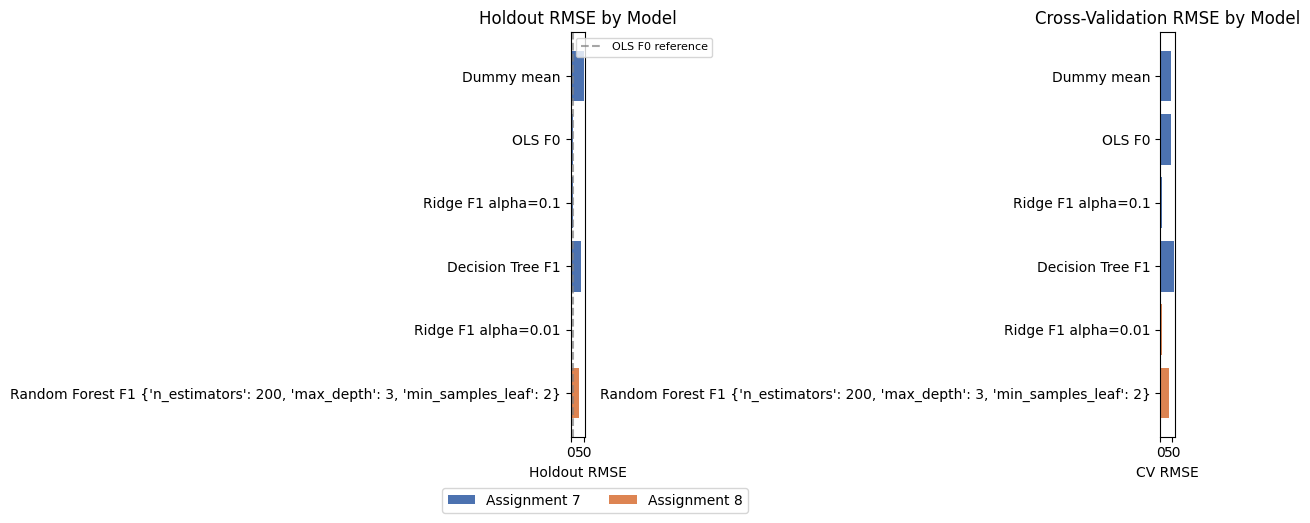

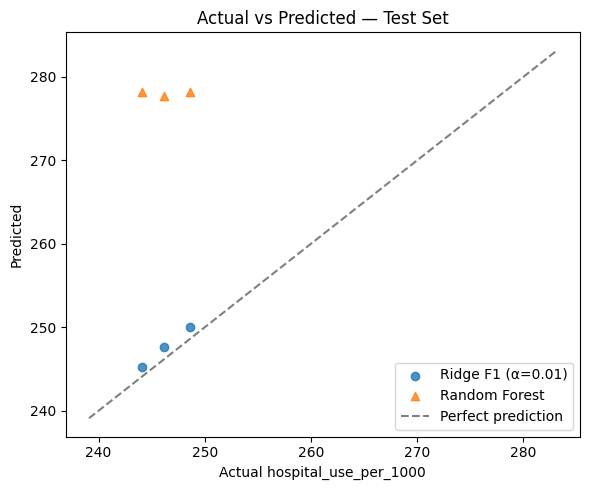

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_labels = [m.split(" (")[0] for m in comp_df["model"]]
colors = ["#4C72B0"] * len(A7_BASELINES) + ["#DD8452"] * len(A8_MODELS)

axes[0].barh(model_labels[::-1], comp_df["test_rmse"].iloc[::-1].values, color=colors[::-1])
axes[0].axvline(7.717, color="gray", linestyle="--", alpha=0.7, label="OLS F0 reference")
axes[0].set_xlabel("Holdout RMSE")
axes[0].set_title("Holdout RMSE by Model")
axes[0].legend(fontsize=8)

axes[1].barh(model_labels[::-1], comp_df["cv_rmse"].iloc[::-1].values, color=colors[::-1])
axes[1].set_xlabel("CV RMSE")
axes[1].set_title("Cross-Validation RMSE by Model")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C72B0", label="Assignment 7"),
                   Patch(facecolor="#DD8452", label="Assignment 8")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# Actual vs Predicted
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.scatter(yte_full, pred_ridge, alpha=0.8, label=f"Ridge F1 (\u03b1={best_alpha})")
ax2.scatter(yte_full, pred_rf, alpha=0.8, marker="^", label="Random Forest")
lo = min(float(yte_full.min()), float(pred_ridge.min()), float(pred_rf.min())) - 5
hi = max(float(yte_full.max()), float(pred_ridge.max()), float(pred_rf.max())) + 5
ax2.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="Perfect prediction")
ax2.set_xlabel("Actual hospital_use_per_1000")
ax2.set_ylabel("Predicted")
ax2.set_title("Actual vs Predicted \u2014 Test Set")
ax2.legend()
plt.tight_layout()
plt.show()